In [ ]:
from huggingface_hub import hf_hub_download
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from PIL import Image
from io import BytesIO
from colpali_engine.models import ColModernVBert, ColModernVBertProcessor
from vidore_benchmark.utils.image_utils import scale_image, get_base64_image

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.backends.mps.is_available():
    device = "mps"  # For Apple Silicon devices
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

In [ ]:
model_id = "ModernVBERT/colmodernvbert"

processor = ColModernVBertProcessor.from_pretrained(model_id)
model = ColModernVBert.from_pretrained(
    model_id,
    torch_dtype=dtype,
    trust_remote_code=True
).to(device).eval()

`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
import requests
from pdf2image import convert_from_path
from pypdf import PdfReader


def download_pdf(url):
    response = requests.get(url)
    if response.status_code == 200:
        return BytesIO(response.content)
    else:
        raise Exception(f"Failed to download PDF: Status code {response.status_code}")


def get_pdf_images(pdf_url):
    # Download the PDF
    pdf_file = download_pdf(pdf_url)
    # Save the PDF temporarily to disk (pdf2image requires a file path)
    with open("temp.pdf", "wb") as f:
        f.write(pdf_file.read())
    reader = PdfReader("temp.pdf")
    page_texts = []
    for page_number in range(len(reader.pages)):
        page = reader.pages[page_number]
        text = page.extract_text()
        page_texts.append(text)
    images = convert_from_path("temp.pdf")
    assert len(images) == len(page_texts)
    return (images, page_texts)

In [ ]:
sample_pdfs = [
    {
        "title": "ColBERTv2: Effective and Efficient Retrieval via Lightweight Late Interaction",
        "url": "https://arxiv.org/pdf/2112.01488.pdf",
        "authors": "Keshav Santhanam, Omar Khattab, Jon Saad-Falcon, Christopher Potts, Matei Zaharia",
    },
    {
        "title": "ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT",
        "url": "https://arxiv.org/pdf/2004.12832.pdf",
        "authors": "Omar Khattab, Matei Zaharia",
    },
]

In [ ]:
for pdf in sample_pdfs:
    page_images, page_texts = get_pdf_images(pdf["url"])
    pdf["images"] = page_images
    pdf["texts"] = page_texts

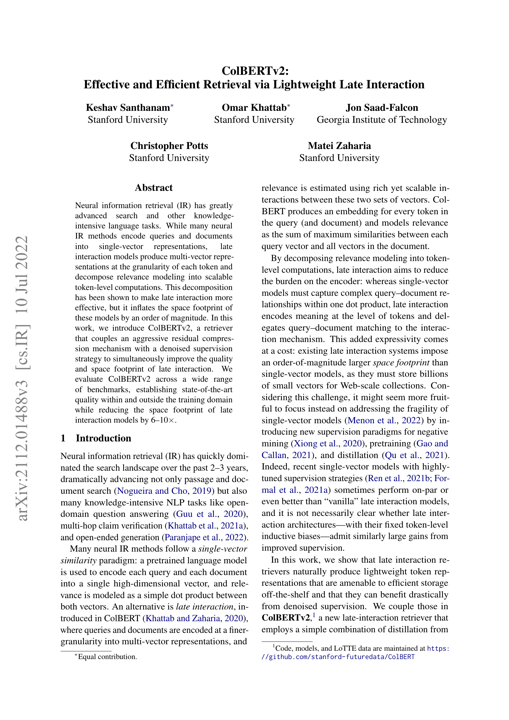

In [ ]:
from IPython.display import display

display(scale_image(sample_pdfs[0]["images"][0], 720))

In [ ]:
for pdf in sample_pdfs:
    page_embeddings = []
    dataloader = DataLoader(
        pdf["images"],
        batch_size=2,
        shuffle=False,
        collate_fn=lambda x: processor.process_images(x),
    )
    for batch_doc in tqdm(dataloader):
        with torch.no_grad():
            batch_doc = {k: v.to(model.device) for k, v in batch_doc.items()}
            embeddings_doc = model(**batch_doc)
            page_embeddings.extend(list(torch.unbind(embeddings_doc.to("cpu"))))
    pdf["embeddings"] = page_embeddings

100%|██████████| 5/5 [02:01<00:00, 24.39s/it]


In [ ]:
import numpy as np
from typing import Dict, List
from binascii import hexlify


def binarize_token_vectors_hex(vectors: List[torch.Tensor]) -> Dict[str, str]:
    vespa_tensor = list()
    for page_id in range(0, len(vectors)):
        page_vector = vectors[page_id]
        binarized_token_vectors = np.packbits(
            np.where(page_vector > 0, 1, 0), axis=1
        ).astype(np.int8)
        for patch_index in range(0, len(page_vector)):
            values = str(
                hexlify(binarized_token_vectors[patch_index].tobytes()), "utf-8"
            )
            if (
                values == "00000000000000000000000000000000"
            ):  # skip empty vectors due to padding of batch
                continue
            vespa_tensor_cell = {
                "address": {"page": page_id, "patch": patch_index},
                "values": values,
            }
            vespa_tensor.append(vespa_tensor_cell)

    return vespa_tensor

In [ ]:
vespa_feed = []
for idx, pdf in enumerate(sample_pdfs):
    images_base_64 = []
    for image in pdf["images"]:
        images_base_64.append(get_base64_image(image, add_url_prefix=False))
    pdf["images_base_64"] = images_base_64
    doc = {
        "id": idx,
        "fields": {
            "url": pdf["url"],
            "title": pdf["title"],
            "images": pdf["images_base_64"],
            "texts": pdf["texts"],  # Array of text per page
            "colbert": {  # Colbert embeddings per page
                "cells": binarize_token_vectors_hex(pdf["embeddings"])
            },
        }
    }
    vespa_feed.append(doc)

In [ ]:
vespa_feed[0]["fields"]["colbert"]["blocks"][0:5]

[{'address': {'page': 0, 'patch': 0},
  'values': '9568a596a41cf1d425ef655f686c9b6c'},
 {'address': {'page': 0, 'patch': 1},
  'values': '93a8a4d6a41ab2d025efee7f287ffb6e'},
 {'address': {'page': 0, 'patch': 2},
  'values': '93aaa6d6a41890f025cfe57f237f9b6c'},
 {'address': {'page': 0, 'patch': 3},
  'values': '952aecd7a014f2c135efc47f3e1d9b26'},
 {'address': {'page': 0, 'patch': 4},
  'values': '99aab4de201cd0f035eb665f3e159b6c'}]

In [ ]:
from vespa.package import Schema, Document, Field, FieldSet, RankProfile

colbert_profile = RankProfile(
    name="colbert",
    inputs=[("query(qt)", "tensor<float>(querytoken{}, v[128])")],
    first_phase="sum(reduce(sum(query(qt) * unpack_bits(attribute(colbert)), v), max, patch), querytoken, page)"
)

colbert_schema = Schema(
    name="doc",
    document=Document(
        fields=[
            Field(name="url", type="string", indexing=["summary"]),
            Field(
                name="title",
                type="string",
                indexing=["summary", "index"],
                index="enable-bm25",
            ),
            Field(
                name="texts",
                type="array<string>",
                indexing=["index"],
                index="enable-bm25",
            ),
            Field(
                name="images",
                type="array<string>",
                indexing=["summary"],
            ),
            Field(
                name="colbert",
                type="tensor<int8>(page{}, patch{}, v[16])",

                indexing=["attribute"],)

            ),    rank_profiles=[colbert_profile]

        ]    fieldsets=[FieldSet(name="default", fields=["title", "texts"])],
    ),

In [ ]:
from vespa.package import ApplicationPackage

vespa_app_name = "vespa"
vespa_application_package = ApplicationPackage(
    name=vespa_app_name, schema=[colbert_schema]
)

In [ ]:
from vespa.deployment import VespaDocker
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Create and deploy to a local Vespa Docker container
# We add volumes to match your manual docker run command for persistence
vespa_docker = VespaDocker(
    volumes={
        "d:/Workspace/Repository/thesis/research/vespa_storage/var": {"bind": "/opt/vespa/var", "mode": "rw"},
        "d:/Workspace/Repository/thesis/research/vespa_storage/logs": {"bind": "/opt/vespa/logs", "mode": "rw"}
    }
)
app = vespa_docker.deploy(
    application_package=vespa_application_package,
    max_wait_configserver=300,
    max_wait_deployment=300)

Waiting for configuration server, 0/300 seconds...
Waiting for configuration server, 5/300 seconds...
Waiting for configuration server, 10/300 seconds...
Waiting for configuration server, 15/300 seconds...
Waiting for configuration server, 20/300 seconds...
Waiting for configuration server, 25/300 seconds...
Waiting for configuration server, 30/300 seconds...
Waiting for configuration server, 35/300 seconds...
Waiting for configuration server, 40/300 seconds...
Waiting for configuration server, 45/300 seconds...
Waiting for configuration server, 50/300 seconds...
Waiting for configuration server, 55/300 seconds...
Waiting for configuration server, 60/300 seconds...
Application is up!
Finished deployment.


In [ ]:
from vespa.io import VespaResponse

def callback(response: VespaResponse, id: str):
    if not response.is_successful():
        print(f"Failed to feed document {id}: {response.get_json()}")

app.feed_iterable(vespa_feed, schema="doc", namespace="visionrag", callback=callback)

Failed to feed document 0: {'Exception': "In document 'id:visionrag:doc::0': Could not parse field 'colbert' of type tensor(page{},patch{},v[16]): At {page:0,patch:0}: Expected 16 values, but got 2", 'id': 0, 'message': 'Exception during feed_data_point'}
Failed to feed document 1: {'Exception': "In document 'id:visionrag:doc::1': Could not parse field 'colbert' of type tensor(page{},patch{},v[16]): At {page:0,patch:0}: Expected 16 values, but got 2", 'id': 1, 'message': 'Exception during feed_data_point'}


In [ ]:
app

Vespa(http://localhost, 8080)

In [ ]:
query = "What is the architecture of ColBERTv2?"

with torch.no_grad():
    query_inputs = processor.process_texts([query]).to(model.device)
    query_embeddings = model(**query_inputs)

# Binarize and format query embeddings for Vespa
# The query tensor expects a float tensor for the multiplication in the rank profile
query_embeddings_np = query_embeddings.cpu().float().numpy()[0]
query_tensor = {
    str(i): query_embeddings_np[i].tolist() for i in range(query_embeddings_np.shape[0])
}

response = app.query(
    body={
        "yql": 'select * from doc where userQuery()',
        "query": query,
        "ranking.profile": "colbert",
        "ranking.features.query(qt)": query_tensor,
    }
)

# Display results
for hit in response.hits:
    print(f"Title: {hit['fields']['title']}")
    print(f"URL: {hit['fields']['url']}")
    print(f"Score: {hit['relevance']}")
    print("-" * 20)

AttributeError: 'Vespa' object has no attribute 'search'

In [ ]:
print(f"Model embedding shape (doc): {pdf['embeddings'][0].shape}")
print(f"Query embedding shape: {query_embeddings.shape}")
print(f"Vespa app methods: {[m for m in dir(app) if not m.startswith('_')]}")

Model embedding shape (doc): torch.Size([1149, 128])
Query embedding shape: torch.Size([1, 13, 128])
Vespa app methods: ['application_package', 'asyncio', 'auth_method', 'base_headers', 'cert', 'delete_all_docs', 'delete_data', 'deployment_message', 'end_point', 'feed_async_iterable', 'feed_data_point', 'feed_iterable', 'get_application_status', 'get_async_session', 'get_data', 'get_document_v1_path', 'get_model_endpoint', 'get_model_from_application_package', 'get_sync_session', 'http', 'key', 'output_file', 'port', 'predict', 'pyvespa_version', 'query', 'query_many', 'query_many_async', 'search_end_point', 'syncio', 'update_data', 'url', 'vespa_cloud_secret_token', 'visit', 'wait_for_application_up']
